In [1]:
import pandas as pd
import os
import numpy as np
from cbir.evaluation import get_topk_guid_retrievals, evaluate_guid_retrieval, evaluate_bias_by_column

DATA_PATH = "/mimer/NOBACKUP/groups/biomedicalimaging-kth/felixnie/"

# Load clinical info
clinical_ds = pd.read_csv(os.path.join(DATA_PATH, "combined_metadata.csv"))
clinical_ds = clinical_ds.query("project == 'oasis3'").reset_index(drop=True)

# Generate fake embeddings
n_feats = 16 
n_scans = len(clinical_ds)
emb_ds = np.random.uniform(-1, 1, (n_scans, n_feats))

# Add to the DataFrame as a new column with list of floats per row
dataset = clinical_ds.copy()
dataset["features"] = [emb for emb in emb_ds]

# Retrive top k for each query
top_k = 5
retrieval_df = get_topk_guid_retrievals(dataset, top_k=top_k)

# Evaluation
top_k = 1
metrics = evaluate_guid_retrieval(retrieval_df, clinical_ds, top_k, class_column="subject")
top_k = 3
metrics = evaluate_guid_retrieval(retrieval_df, clinical_ds, top_k, class_column="subject")
top_k = 5
metrics = evaluate_guid_retrieval(retrieval_df, clinical_ds, top_k, class_column="subject")

# Evaluate bias
top_k = 1
metrics_bias = evaluate_bias_by_column(retrieval_df, clinical_ds, top_k=top_k, class_column='subject', group_by_column='field_strength')
metrics_bias = evaluate_bias_by_column(retrieval_df, clinical_ds, top_k=top_k, class_column='subject', group_by_column='manufacturer')
metrics_bias = evaluate_bias_by_column(retrieval_df, clinical_ds, top_k=top_k, class_column='subject', group_by_column='model_name')

top_k = 3
metrics_bias = evaluate_bias_by_column(retrieval_df, clinical_ds, top_k=top_k, class_column='subject', group_by_column='field_strength')
metrics_bias = evaluate_bias_by_column(retrieval_df, clinical_ds, top_k=top_k, class_column='subject', group_by_column='manufacturer')
metrics_bias = evaluate_bias_by_column(retrieval_df, clinical_ds, top_k=top_k, class_column='subject', group_by_column='model_name')

top_k = 5
metrics_bias = evaluate_bias_by_column(retrieval_df, clinical_ds, top_k=top_k, class_column='subject', group_by_column='field_strength')
metrics_bias = evaluate_bias_by_column(retrieval_df, clinical_ds, top_k=top_k, class_column='subject', group_by_column='manufacturer')
metrics_bias = evaluate_bias_by_column(retrieval_df, clinical_ds, top_k=top_k, class_column='subject', group_by_column='model_name')

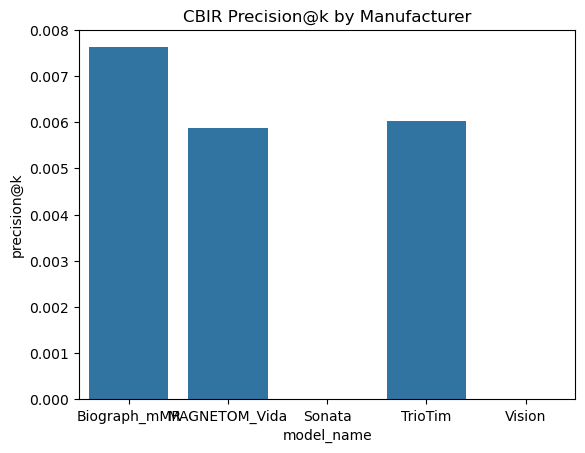

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

sns.barplot(data=metrics_bias, x='model_name', y='precision@k')
plt.title("CBIR Precision@k by Manufacturer")
plt.show()
